# **Phần 1 - Bài toán Hồi quy (Regression)**
## **1. Import thư viện & hàm**

In [36]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from utils import read_data, drop_unnecessary_columns, filter_and_clean_order_status, initialize_target_variable,handle_duplicates
from utils import optimize_logistics_timestamps, fill_product_specs_smart, handle_category_missing, standardize_column_formats

from utils import compare_outlier_methods,summarize_outliers


## **2. Định nghĩa đường dẫn**

In [2]:
# Đường dẫn tương đối của file dữ liệu
path = "../../data/"
# Kiểm tra đường dẫn có tồn tại không 
if not os.path.exists(path):
    print(f"Đường dẫn {path} không tồn tại.")
else:
    print(f"Đường dẫn {path} tồn tại.")

Đường dẫn ../../data/ tồn tại.


## **3. Mô tả dữ liệu** 
### **a. Orders Data**

Bảng này chứa thông tin về các đơn hàng được khách hàng đặt trên các nền tảng thương mại điện tử. Mỗi dòng đại diện cho một đơn hàng riêng biệt của khách hàng 
<div align="center">

| Feature                          | Mô tả                                                                 |
|----------------------------------|----------------------------------------------------------------------|
| order_id                         | Mã định danh duy nhất cho mỗi đơn hàng                              |
| customer_id                      | Mã định danh duy nhất của khách hàng đặt đơn                        |
| order_status                     | Trạng thái hiện tại của đơn hàng (ví dụ: đã giao, đang giao, đã hủy)|
| order_purchase_timestamp         | Thời điểm khách hàng đặt đơn hàng                                   |
| order_approved_at                | Thời điểm đơn hàng được xác nhận                                    |
| order_delivered_carrier_date     | Thời điểm đơn hàng được bàn giao cho đơn vị vận chuyển              |
| order_delivered_customer_date    | Thời điểm đơn hàng được giao đến khách hàng                         |
| order_estimated_delivery_date    | Ngày dự kiến giao hàng                                              |
</div>

In [3]:
orders_df = read_data(path, "olist_orders_dataset.csv")
print('Orders Data Shape: ',orders_df.shape)
display(orders_df.head())
print("Orders Data Info:")
display(orders_df.info())

Đang đọc dữ liệu từ olist_orders_dataset.csv...
Orders Data Shape:  (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Orders Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


None

### **b. Orders items**

Bảng này chứa thông tin về các mặt hàng được đặt mua trong hệ thống thương mại điện tử. Mỗi hàng đại diện cho một mặt hàng trong một đơn đặt hàng.
<div align='center'>

| Feature              | Mô tả                                                                 |
|---------------------|----------------------------------------------------------------------|
| order_id            | Mã định danh duy nhất của đơn hàng                                   |
| order_item_id       | Số thứ tự của từng sản phẩm trong cùng một đơn hàng                  |
| product_id          | Mã định danh duy nhất của sản phẩm                                   |
| seller_id           | Mã định danh duy nhất của người bán sản phẩm                         |
| shipping_limit_date | Hạn chót để sản phẩm được gửi đi                                    |
| price               | Giá của sản phẩm                                                     |
| freight_value       | Chi phí vận chuyển của sản phẩm                                     |

</div>

In [4]:
order_items_df = read_data(path, "olist_order_items_dataset.csv")
print("Orders items Data Shape: ", order_items_df.shape)
display(order_items_df.head())
print("Orders items Data Info:")
display(order_items_df.info())  

Đang đọc dữ liệu từ olist_order_items_dataset.csv...
Orders items Data Shape:  (112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


Orders items Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


None

### **c. Customers** 

Bảng này chứa thông tin về khách hàng. Mỗi hàng trong bảng đại diện cho một khách hàng, mỗi khách hàng được xác định bằng các thuộc tính hoặc đặc điểm được thể hiện bởi các cột trong bảng.
<div align='center'>

| Feature                    | Mô tả                                                                 |
|---------------------------|----------------------------------------------------------------------|
| customer_id               | Mã định danh duy nhất cho mỗi lần giao dịch hoặc tương tác của khách hàng |
| customer_unique_id        | Mã định danh duy nhất cho mỗi khách hàng                             |
| customer_zip_code_prefix  | Tiền tố mã bưu điện của địa chỉ khách hàng                          |
| customer_city             | Thành phố của khách hàng                                             |
| customer_state            | Bang (khu vực) của khách hàng                                        |

</div>

In [5]:
customers_df = read_data(path, "olist_customers_dataset.csv")   
print("Customers Data Shape: ", customers_df.shape)
display(customers_df.head())
print("Customers Data Info:")
display(customers_df.info())  

Đang đọc dữ liệu từ olist_customers_dataset.csv...
Customers Data Shape:  (99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Customers Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


None

### **d. Sellers**

Bảng này cung cấp thông tin về người bán đã đăng ký ở trên nền tảng bán hàng. Mỗi dòng mô tả chi tiết về một người bán 
<div align='center'>

| Feature                 | Mô tả                                                           |
|------------------------|-----------------------------------------------------------------|
| seller_id              | Mã định danh duy nhất cho mỗi người bán                         |
| seller_zip_code_prefix | Tiền tố mã bưu điện của địa chỉ người bán                      |
| seller_city            | Thành phố nơi người bán hoạt động                               |
| seller_state           | Bang (khu vực) nơi người bán hoạt động                          |

</div>

In [6]:
sellers_df = read_data(path, "olist_sellers_dataset.csv")
print("Sellers Data Shape: ", sellers_df.shape)
display(sellers_df.head())
print("Sellers Data Info:")
display(sellers_df.info())


Đang đọc dữ liệu từ olist_sellers_dataset.csv...
Sellers Data Shape:  (3095, 4)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


Sellers Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


None

### **e. Products**

Bảng này chứa tập hợp dữ liệu sản phẩm từ các nền tảng thương mại điện tử, bao gồm thông tin về nhiều sản phẩm khác nhau như mô tả sản phẩm hoặc kích thước.
<div align='center'>

| Feature                        | Mô tả                                                                 |
|--------------------------------|----------------------------------------------------------------------|
| product_id                     | Mã định danh duy nhất của sản phẩm                                   |
| product_category_name          | Danh mục mà sản phẩm thuộc về                                        |
| product_name_lenght            | Độ dài tên sản phẩm (số ký tự)                                       |
| product_description_lenght     | Độ dài mô tả sản phẩm (số ký tự)                                     |
| product_photos_qty             | Số lượng hình ảnh của sản phẩm                                       |
| product_weight_g               | Trọng lượng sản phẩm (tính bằng gram)                               |
| product_length_cm              | Chiều dài sản phẩm (cm)                                              |
| product_height_cm              | Chiều cao sản phẩm (cm)                                              |
| product_width_cm               | Chiều rộng sản phẩm (cm)                                             |

</div>

In [7]:
products_df = read_data(path, "olist_products_dataset.csv")
print("Products Data Shape: ", products_df.shape)
display(products_df.head())
print("Products Data Info:")
display(products_df.info())

Đang đọc dữ liệu từ olist_products_dataset.csv...
Products Data Shape:  (32951, 9)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Products Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


None

### **f. Translation** 

Bảng này chứa tập dữ liệu dịch tên danh mục sản phẩm, được sử dụng để dịch tên danh mục sản phẩm từ tiếng Bồ Đào Nha sang tiếng Anh.
<div align='center'>

| Feature                         | Mô tả                                                      |
|---------------------------------|-----------------------------------------------------------|
| product_category_name           | Tên danh mục sản phẩm gốc bằng tiếng Bồ Đào Nha           |
| product_category_name_english   | Tên danh mục sản phẩm đã được dịch sang tiếng Anh         |

</div>

In [8]:
category_translation_df = read_data(path, "product_category_name_translation.csv")
print("Translation Data Shape: ", category_translation_df.shape)
display(category_translation_df.head())
print("Translation Data Info:")
display(category_translation_df.info())


Đang đọc dữ liệu từ product_category_name_translation.csv...
Translation Data Shape:  (71, 2)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


Translation Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


None

### **g. Geolocation** 
Bảng này chứa dữ liệu xác định vị trí địa lý trong thế giới thực hoặc vị trí vật lý của các đối tượng khác nhau thông qua tọa độ GPS. Mỗi hàng đại diện cho một vị trí địa lý duy nhất.

<div align='center'>

| Feature                       | Mô tả                                                                 |
|-------------------------------|----------------------------------------------------------------------|
| geolocation_zip_code_prefix   | Tiền tố mã bưu điện (CEP) của Brazil cho một khu vực cụ thể          |
| geolocation_lat              | Tọa độ vĩ độ của vị trí                                             |
| geolocation_lng              | Tọa độ kinh độ của vị trí                                           |
| geolocation_city             | Tên thành phố tương ứng với vị trí địa lý                           |
| geolocation_state            | Tên bang (khu vực) tương ứng với vị trí địa lý                      |

</div>

In [9]:
geolocation_df = read_data(path, "olist_geolocation_dataset.csv")
print("Geolocation Data Shape: ", geolocation_df.shape)
display(geolocation_df.head())
print("Geolocation Data Info:")
display(geolocation_df.info())

Đang đọc dữ liệu từ olist_geolocation_dataset.csv...
Geolocation Data Shape:  (1000163, 5)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


Geolocation Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB


None

## **4. Gộp và loại bỏ những cột dữ liệu không cần thiết**
- Gộp dữ liệu

In [10]:
# Merge các DataFrame lại với nhau
df = pd.merge(orders_df, customers_df, on='customer_id', how='left')
df = df.merge(order_items_df, on='order_id', how='left')
df = df.merge(sellers_df, on='seller_id', how='left')
df = df.merge(products_df, on='product_id', how='left')
df = df.merge(category_translation_df, on='product_category_name', how='left')

print('Merge Data Shape:',df.shape)
display(df.head())

Merge Data Shape: (113425, 30)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,seller_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,SP,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,SP,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,MG,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,SP,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


- Xóa các cột dữ liệu không cần thiết 

In [11]:
df_raw = drop_unnecessary_columns(df)
print('Final Data Shape:', df_raw.shape)
display(df_raw.head())

--- ĐÃ LÀM SẠCH CỘT ---
Tổng số cột ban đầu: 30
Số cột đã bị loại bỏ: 12
Số cột còn lại: 18
Final Data Shape: (113425, 18)


,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,shipping_limit_date,price,freight_value,seller_city,seller_state,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,sao paulo,SP,2017-10-06 11:07:15,29.99,8.72,maua,SP,500.0,19.0,8.0,13.0,housewares
1,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,barreiras,BA,2018-07-30 03:24:27,118.70,22.76,belo horizonte,SP,400.0,19.0,13.0,19.0,perfumery
2,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,vianopolis,GO,2018-08-13 08:55:23,159.90,19.22,guariba,SP,420.0,24.0,19.0,21.0,auto
3,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,sao goncalo do amarante,RN,2017-11-23 19:45:59,45.00,27.20,belo horizonte,MG,450.0,30.0,10.0,20.0,pet_shop
4,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,santo andre,SP,2018-02-19 20:31:37,19.90,8.72,mogi das cruzes,SP,250.0,51.0,15.0,15.0,stationery


- Chỉ giữ lại các dòng dữ liệu giao hàng thành công và xóa bỏ cột order_status

In [12]:
df_clean = filter_and_clean_order_status(df_raw)
print('Cleaned Data Shape:', df_clean.shape)
display(df_clean.head())

--- ĐÃ LỌC ĐƠN HÀNG ---
Tổng số đơn hàng ban đầu: 113425
Số đơn hàng đã bị loại bỏ (chưa giao hoặc lỗi ngày): 3236
Số đơn hàng còn lại: 110189
Cleaned Data Shape: (110189, 17)


,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,shipping_limit_date,price,freight_value,seller_city,seller_state,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,sao paulo,SP,2017-10-06 11:07:15,29.99,8.72,maua,SP,500.0,19.0,8.0,13.0,housewares
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,barreiras,BA,2018-07-30 03:24:27,118.70,22.76,belo horizonte,SP,400.0,19.0,13.0,19.0,perfumery
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,vianopolis,GO,2018-08-13 08:55:23,159.90,19.22,guariba,SP,420.0,24.0,19.0,21.0,auto
3,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,sao goncalo do amarante,RN,2017-11-23 19:45:59,45.00,27.20,belo horizonte,MG,450.0,30.0,10.0,20.0,pet_shop
4,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,santo andre,SP,2018-02-19 20:31:37,19.90,8.72,mogi das cruzes,SP,250.0,51.0,15.0,15.0,stationery


- Tính toán biến mục tiêu và lưu dữ liệu vào file csv

In [13]:
df_final = initialize_target_variable(df_clean)
df_final.to_csv(f"{path}raw_data.csv",index =False)

--- KHỞI TẠO BIẾN MỤC TIÊU ---
- Số dòng bị loại bỏ (do thiếu ngày giao hoặc lỗi logic): 0
- Số lượng mẫu còn lại: 110189
- Thời gian giao hàng trung bình trong tập dữ liệu: 12.47 ngày


## **5. Thống kê mô tả dữ liệu sau khi gộp**

In [14]:
print(f"Kích thước của dữ liệu: {df_final.shape}")
df_final.info()

Kích thước của dữ liệu: (110189, 18)
<class 'pandas.DataFrame'>
Index: 110189 entries, 0 to 113424
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_purchase_timestamp       110189 non-null  datetime64[us]
 1   order_approved_at              110174 non-null  str           
 2   order_delivered_carrier_date   110188 non-null  str           
 3   order_delivered_customer_date  110189 non-null  datetime64[us]
 4   order_estimated_delivery_date  110189 non-null  str           
 5   customer_city                  110189 non-null  str           
 6   customer_state                 110189 non-null  str           
 7   shipping_limit_date            110189 non-null  str           
 8   price                          110189 non-null  float64       
 9   freight_value                  110189 non-null  float64       
 10  seller_city                    110189 non-null 

In [15]:
df_final.describe().T

,count,mean,min,25%,50%,75%,max,std
order_purchase_timestamp,110189,2018-01-02 02:39:32.673824,2016-09-15 12:16:38,2017-09-15 04:48:38,2018-01-21 09:13:44,2018-05-05 15:38:37,2018-08-29 15:00:37,NaN
order_delivered_customer_date,110189,2018-01-14 13:59:34.689260,2016-10-11 13:46:32,2017-09-26 20:15:35,2018-02-02 21:05:09,2018-05-15 20:14:33,2018-10-17 13:22:46,NaN
price,110189.0,119.977937,0.85,39.9,74.9,134.17,6735.0,182.304615
freight_value,110189.0,19.948869,0.0,13.08,16.26,21.15,409.68,15.698615
product_weight_g,110171.0,2089.687813,0.0,300.0,700.0,1800.0,40425.0,3741.682542
product_length_cm,110171.0,30.142551,7.0,18.0,25.0,38.0,105.0,16.122279
product_height_cm,110171.0,16.555427,2.0,8.0,13.0,20.0,105.0,13.409562
product_width_cm,110171.0,22.986258,6.0,15.0,20.0,30.0,118.0,11.68796
target_delivery_days,110189.0,12.472246,0.533414,6.736192,10.184201,15.54081,209.628611,9.445346


## **6. Phân tích khám phá (EDA)**
### **a. Biểu đồ 1: Phân phối biến mục tiêu**

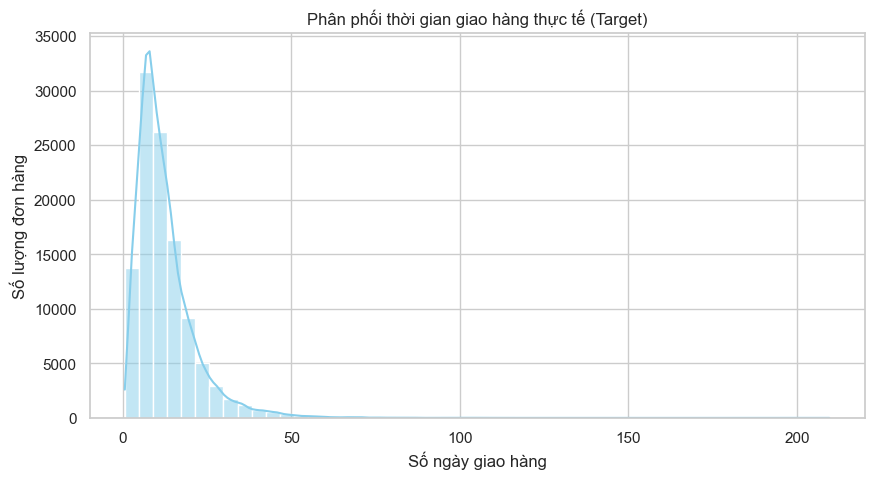

In [16]:
#df_final['order_purchase_timestamp'] = pd.to_datetime(df_final['order_purchase_timestamp'])
sns.set(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.histplot(df_final['target_delivery_days'], bins=50, kde=True, color='skyblue')
plt.title('Phân phối thời gian giao hàng thực tế (Target)')
plt.xlabel('Số ngày giao hàng')
plt.ylabel('Số lượng đơn hàng')
plt.show()

#### Nhận xét: Dữ liệu lệch phải. Đa số đơn hàng giao dưới 20 ngày.

### **b. Biểu đồ 2: Ma trận tương quan**

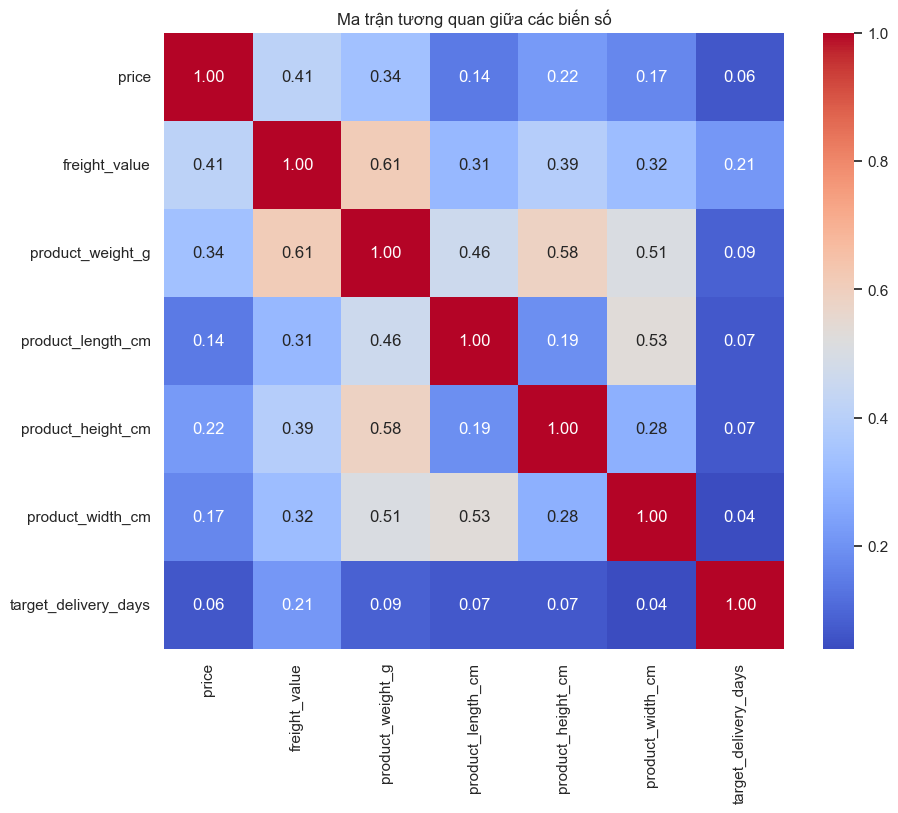

In [17]:
plt.figure(figsize=(10,8))
numerical_cols = ['price', 'freight_value', 'product_weight_g', 
                  'product_length_cm', 'product_height_cm', 
                  'product_width_cm', 'target_delivery_days']
sns.heatmap(df_final[numerical_cols].corr(), annot = True, cmap ='coolwarm', fmt ='.2f')
plt.title("Ma trận tương quan giữa các biến số")
plt.show()


#### Nhận xét:
- 'freight_value' (phí ship) và 'product_weight_g' (trọng lượng) có tương quan thuận mạnh (0.61).
- 'price' không ảnh hưởng nhiều đến thời gian giao hàng.
### **c. Biểu đồ 3: Boxplot theo Bang**

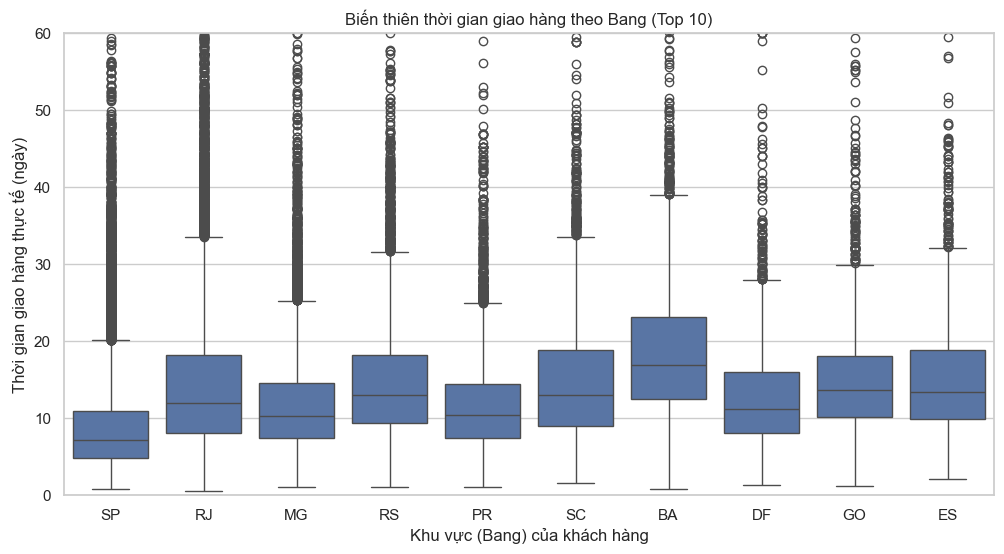

In [18]:
top_states = df_final['customer_state'].value_counts().nlargest(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(x='customer_state', y='target_delivery_days', 
            data=df_final[df_final['customer_state'].isin(top_states)], order=top_states)
plt.title('Biến thiên thời gian giao hàng theo Bang (Top 10)')
plt.ylim(0, 60) # Giới hạn để thấy được phần lớn dữ liệu
plt.ylabel("Thời gian giao hàng thực tế (ngày)")
plt.xlabel("Khu vực (Bang) của khách hàng")
plt.show()

#### Nhận xét:
- Bang SP (Sao Paulo) có thời gian giao hàng nhanh và ổn định nhất.
- Các bang xa trung tâm như BA (Bahia) có thời gian giao hàng trung bình cao hơn và dải biến thiên rộng.
### **d. Biểu đồ 4: Xu hướng theo thời gian**

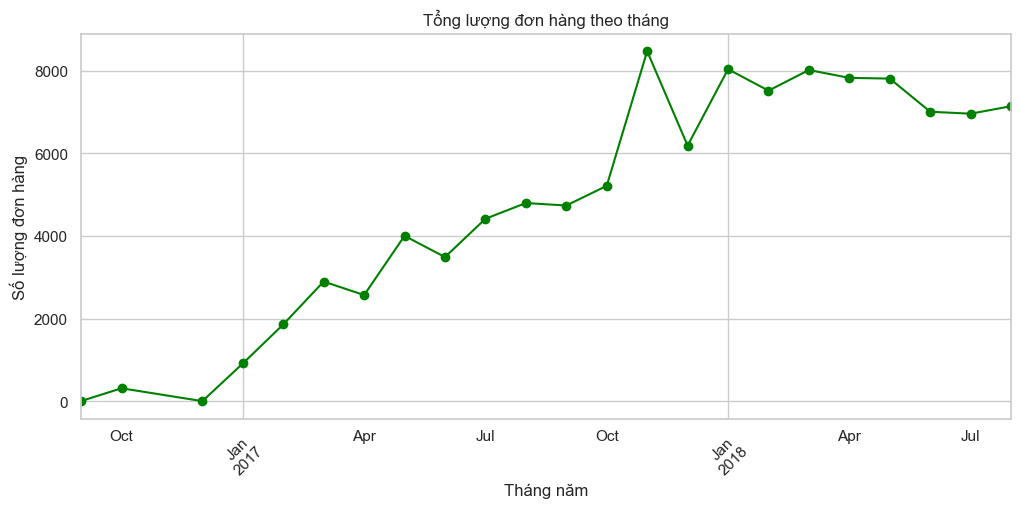

In [19]:
df_final['month_year'] = df_final['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = df_final.groupby('month_year').size()
plt.figure(figsize=(12, 5))
monthly_orders.plot(kind='line', marker='o', color='green')
plt.title('Tổng lượng đơn hàng theo tháng')
plt.xticks(rotation=45)
plt.ylabel("Số lượng đơn hàng")
plt.xlabel("Tháng năm")
plt.show()

#### Nhận xét: Lượng đơn hàng tăng trưởng đều theo thời gian, có đỉnh cao vào cuối năm 2017 (Black Friday).
#### **e. Biểu đồ 5: Top danh mục sản phẩm**

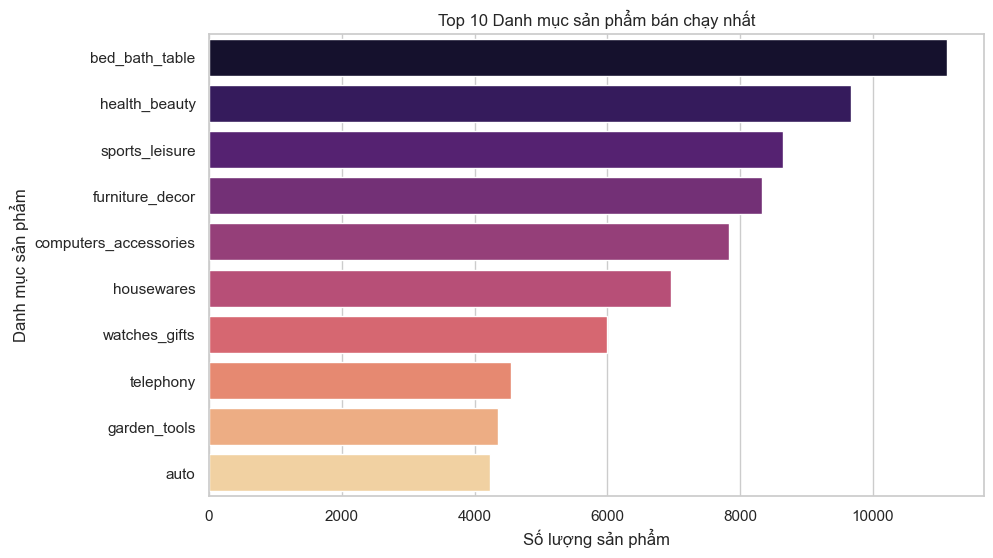

In [20]:
top_cats = df['product_category_name_english'].value_counts().nlargest(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_cats.values, 
    y=top_cats.index, 
    hue=top_cats.index, 
    palette='magma', 
    legend=False
)
plt.title('Top 10 Danh mục sản phẩm bán chạy nhất')
plt.ylabel('Danh mục sản phẩm')
plt.xlabel('Số lượng sản phẩm')
plt.show()

### **f. Thời gian giao hàng trung bình theo từng `Ngày` trong tuần**

In [21]:
print(df_final.columns)

Index(['order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_city', 'customer_state',
       'shipping_limit_date', 'price', 'freight_value', 'seller_city',
       'seller_state', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'target_delivery_days', 'month_year'],
      dtype='str')


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3148\924455341.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='order_weekday', y='target_delivery_days', data=df_final, order=weekday_order, palette='viridis')


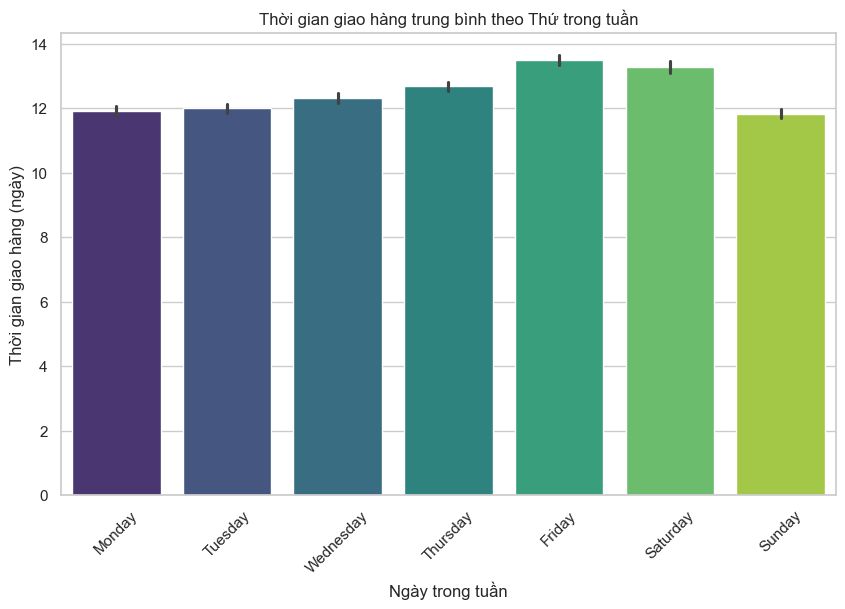

In [22]:
df_final['order_weekday'] = df_final['order_purchase_timestamp'].dt.day_name()
df_final['order_month'] = df_final['order_purchase_timestamp'].dt.month
# display(df_final['order_month'].head)
# display(df_final['order_weekday'].head)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(10,6))
sns.barplot(x='order_weekday', y='target_delivery_days', data=df_final, order=weekday_order, palette='viridis')
plt.title('Thời gian giao hàng trung bình theo Thứ trong tuần')
plt.xlabel('Ngày trong tuần')
plt.ylabel('Thời gian giao hàng (ngày)')
plt.tick_params(axis='x', rotation=45)

#### `Nhận xét:` 
- Khi một khách hàng đặt mua vào Thứ 5 hoặc Thứ 6, đơn hàng cần 1-2 ngày để người bán đóng gói và giao cho đơn vị vận chuyển (carrier). Trớ trêu thay, lúc gói hàng bắt đầu đi vào trung tâm trung chuyển thì lại vướng ngay vào Thứ 7 và Chủ Nhật — hai ngày mà các công ty bưu chính (như Correios của Brazil) thường nghỉ việc hoặc giảm công suất tối đa. Hậu quả là gói hàng bị "đóng băng" lưu kho mất 2 ngày, làm tổng thời gian (tính theo ngày lịch) bị dội lên.

- Nếu khách đặt hàng vào Chủ Nhật, hệ thống sẽ ghi nhận và người bán có thể xử lý ngay vào sáng sớm Thứ 2. Gói hàng này sẽ có một đường băng dài trọn vẹn 5 ngày làm việc liên tục (Thứ 2 đến Thứ 6) để di chuyển xuyên bang mà không bị cản trở bởi ngày nghỉ nào.

### **g. Sự thay đổi của thời gian giao hàng theo `Tháng`**

([<matplotlib.axis.XTick at 0x18d3a7165d0>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12')])

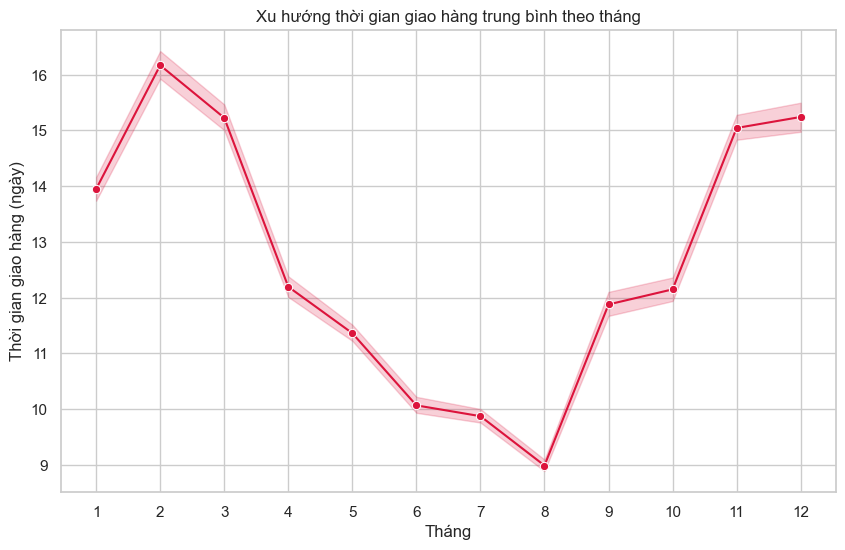

In [23]:
plt.figure(figsize=(10,6))
sns.lineplot(x='order_month', y='target_delivery_days', data=df_final, marker='o', color='crimson')
plt.title('Xu hướng thời gian giao hàng trung bình theo tháng')
plt.xlabel('Tháng')
plt.ylabel('Thời gian giao hàng (ngày)')
plt.xticks(range(1,13))

#### `Nhận xét`
- Đỉnh điểm giao hàng chậm nhất `(Tháng 2)`: Thời gian giao hàng vọt lên mức cao nhất trong năm (hơn 16 ngày).

    - Nguyên nhân: Đây là thời điểm diễn ra Lễ hội **Carnival** tại Brazil. Đây là kỳ nghỉ lễ lớn nhất quốc gia kéo dài nhiều ngày, khiến toàn bộ hệ thống bưu điện và vận chuyển đình trệ, hàng hóa bị lưu kho chờ qua lễ mới được xử lý.

- Giai đoạn quá tải cuối năm `(Tháng 11 & 12)`: Thời gian giao hàng tăng mạnh trở lại, đạt mốc trên 15 ngày.

    - Nguyên nhân: Đây là mùa siêu mua sắm với `Black Friday (tháng 11)` và `Giáng sinh (tháng 12)`. Lượng đơn hàng bùng nổ đột biến làm vượt quá công suất xử lý của các kho bãi và trung tâm phân phối (bottleneck), dẫn đến việc giao hàng bị chậm trễ diện rộng.

- Giai đoạn "Vàng" của Logistics `(Tháng 4 đến Tháng 8):` Thời gian giao hàng giảm liên tục và chạm đáy (nhanh nhất) vào tháng 8 (chỉ khoảng 9 ngày).

    - Nguyên nhân: Đây là giai đoạn giữa năm, không có các đợt sale lớn hay kỳ nghỉ lễ quốc gia dài ngày. Khối lượng đơn hàng duy trì ở mức ổn định, giúp các đơn vị vận chuyển tối ưu hóa được tốc độ xử lý.

### **h. So sánh thời gian vận chuyển theo 10 Danh mục sản phẩm phổ biến nhất**

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3148\2759968688.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='target_delivery_days', y='product_category_name_english', data=df_top10_cat,
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3148\2759968688.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='target_delivery_days', y='product_category_name_english', data=df_top10_cat,


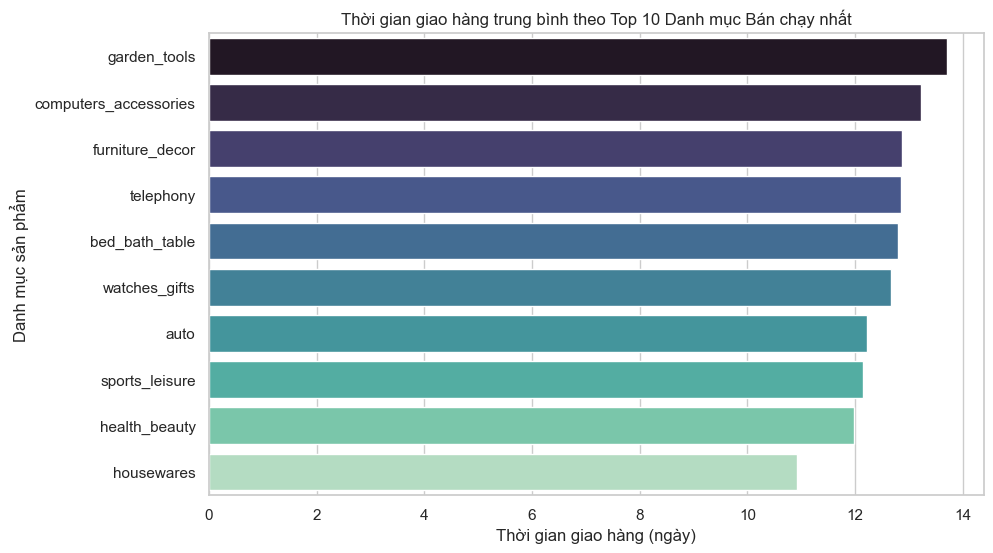

In [24]:
top_10_cats = df_final['product_category_name_english'].value_counts().nlargest(10).index 
df_top10_cat = df_final[df_final['product_category_name_english'].isin(top_10_cats)]
plt.figure(figsize=(10,6))
order = df_top10_cat.groupby('product_category_name_english')['target_delivery_days'].mean().sort_values(ascending=False).index 
sns.barplot(x='target_delivery_days', y='product_category_name_english', data=df_top10_cat, 
            order=order, palette='mako', ci=None)
plt.title('Thời gian giao hàng trung bình theo Top 10 Danh mục Bán chạy nhất')
plt.xlabel('Thời gian giao hàng (ngày)')
plt.ylabel('Danh mục sản phẩm')
plt.show()

#### `Nhận xét:`
- Nhóm giao hàng chậm nhất (Đồ điện tử & Nội thất): `computers_accessories (Phụ kiện máy tính)` và `furniture_decor (Nội thất/Trang trí)` dẫn đầu với thời gian giao hàng trung bình hơn 13 ngày.

    - Nguyên nhân: Đồ nội thất thường có kích thước cồng kềnh, quá khổ, bắt buộc phải dùng các dịch vụ vận chuyển chuyên biệt (xe tải lớn) thay vì bưu kiện tiêu chuẩn, dẫn đến thời gian chờ ghép chuyến lâu hơn. Phụ kiện máy tính thường là hàng điện tử giá trị cao, dễ vỡ, đòi hỏi quy trình đóng gói chống sốc khắt khe và đôi khi cần thủ tục bảo hiểm hàng hóa trước khi xuất kho.

- Nhóm giao hàng nhanh nhất (Hàng tiêu dùng nhỏ gọn): `housewares (Đồ gia dụng)`, `toys (Đồ chơi)` và `health_beauty (Sức khỏe & Sắc đẹp)` mất ít thời gian nhất `(chỉ khoảng 11 - 12 ngày)`.

    - Nguyên nhân: Đây là những mặt hàng tiêu chuẩn, kích thước nhỏ gọn, không yêu cầu bảo quản đặc biệt. Chúng dễ dàng được xử lý tự động, đóng gói nhanh và có thể vận chuyển bằng mọi phương tiện cơ bản (thậm chí là xe máy giao hàng).

### **i. Phân phối thời gian vận chuyển trên khắp các Bang khách hàng tại Brazil**

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3148\834783963.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='customer_state', y='target_delivery_days', data=df_final,
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3148\834783963.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='customer_state', y='target_delivery_days', data=df_final,


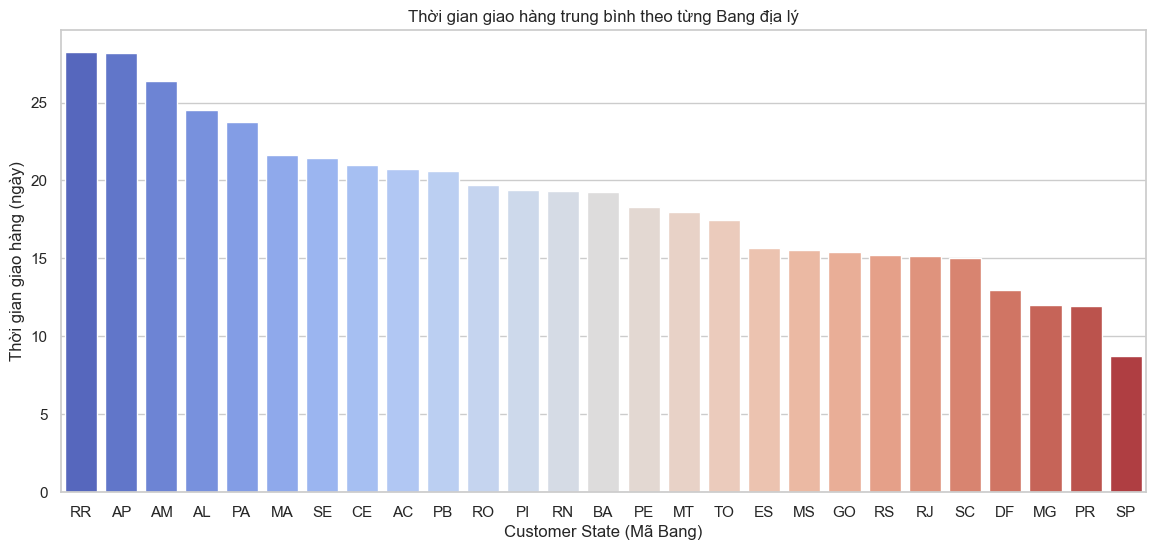

In [25]:
plt.figure(figsize=(14, 6))
# Sắp xếp các bang theo thời gian giao hàng trung bình giảm dần
state_order = df_final.groupby('customer_state')['target_delivery_days'].mean().sort_values(ascending=False).index

sns.barplot(x='customer_state', y='target_delivery_days', data=df_final, 
            order=state_order, palette='coolwarm', ci=None)
plt.title('Thời gian giao hàng trung bình theo từng Bang địa lý')
plt.xlabel('Customer State (Mã Bang)')
plt.ylabel('Thời gian giao hàng (ngày)')
plt.show()


#### `Nhận xét:`
- Nhóm `"Siêu tốc" (SP, PR, MG, RJ)`: Các bang như `São Paulo (SP), Paraná (PR), Minas Gerais (MG) và Rio de Janeiro (RJ)` có thời gian giao hàng thấp nhất `(khoảng 8 - 11 ngày)`.

    - Nguyên nhân: Đây là vùng tam giác kinh tế phía Đông Nam và Nam của Brazil. Hầu hết các kho hàng (warehouses) của người bán trên Olist tập trung tại `São Paulo`. Khoảng cách ngắn, hạ tầng đường bộ tốt và mật độ bưu cục dày đặc giúp việc giao hàng cực kỳ nhanh chóng.

- Nhóm `"Rùa bò" (RR, AP, AM, AL)`: Các bang vùng xa như `Roraima (RR), Amapá (AP), Amazonas (AM)` có thời gian giao hàng trung bình lên tới `25 - 30 ngày (gấp 3 lần vùng trung tâm)`.

    - Nguyên nhân: Đây là các bang thuộc vùng Amazon (phía Bắc) hoặc vùng ven biển phía Đông Bắc. Địa hình bị chia cắt bởi sông ngòi, rừng rậm, hạ tầng giao thông kém phát triển. Nhiều đơn hàng đến đây phải kết hợp cả đường bộ, đường thủy và đường hàng không, dẫn đến thời gian chờ đợi khủng khiếp.



### **j. Phân bố hiện trạng của ngoại lai (Outliers) đối với chi phí, kích cỡ và mục tiêu giao hàng**

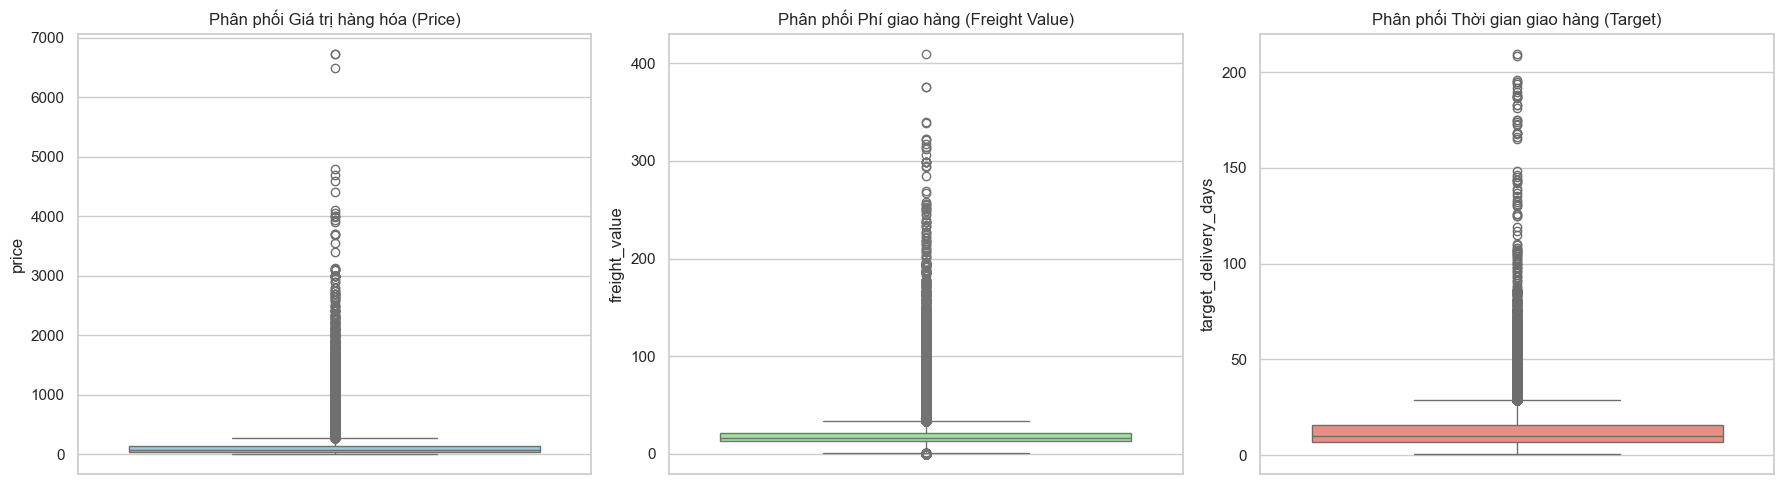

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Boxplot cho 3 giá trị liên tục cốt lõi
sns.boxplot(y=df_final['price'], ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối Giá trị hàng hóa (Price)')
sns.boxplot(y=df_final['freight_value'], ax=axes[1], color='lightgreen')
axes[1].set_title('Phân phối Phí giao hàng (Freight Value)')
sns.boxplot(y=df_final['target_delivery_days'], ax=axes[2], color='salmon')
axes[2].set_title('Phân phối Thời gian giao hàng (Target)')
plt.tight_layout()
plt.show()


#### `Nhận xét:`

## **7. Tiền xử lý dữ liệu**
### **a. Xử lý missing values**

In [27]:
print("Thống kê số lượng giá trị còn thiếu ở mỗi cột:")
print(df_final.isnull().sum())

Thống kê số lượng giá trị còn thiếu ở mỗi cột:
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date        1
order_delivered_customer_date       0
order_estimated_delivery_date       0
customer_city                       0
customer_state                      0
shipping_limit_date                 0
price                               0
freight_value                       0
seller_city                         0
seller_state                        0
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
product_category_name_english    1559
target_delivery_days                0
month_year                          0
order_weekday                       0
order_month                         0
dtype: int64


- Xử lý giá trị thiếu ở 2 cột order_approved_at và order_delivered_carrier_date

In [28]:
df_final = optimize_logistics_timestamps(df_final)

--- Xử lý cột: order_approved_at ---
   + Số dòng đã điền: 15
   + Khoảng lệch trung vị (Median): 0.35 giờ
------------------------------
--- Xử lý cột: order_delivered_carrier_date ---
   + Số dòng đã điền: 1
   + Khoảng lệch trung vị (Median): 44.06 giờ
------------------------------


- Xử lý giá trị thiếu ở các cột kích thước sản phẩm

In [29]:
df_final = fill_product_specs_smart(df_final)

--- XỬ LÝ KÍCH THƯỚC & TRỌNG LƯỢNG ---
-> Cột product_weight_g: Đã điền 18 dòng. (Global Median dùng: 700.0)
-> Cột product_length_cm: Đã điền 18 dòng. (Global Median dùng: 25.0)
-> Cột product_height_cm: Đã điền 18 dòng. (Global Median dùng: 13.0)
-> Cột product_width_cm: Đã điền 18 dòng. (Global Median dùng: 20.0)


- Xử lý giá trị thiếu ở cột phân loại sản phẩm

In [30]:
df_final = handle_category_missing(df_final)

--- XỬ LÝ DANH MỤC ---
-> Đã điền 1559 dòng trống bằng nhãn 'other'.


### **b. Chuẩn hóa định dạng dữ liệu**

In [31]:
df_final = standardize_column_formats(df_final)

--- CHUẨN HÓA ĐỊNH DẠNG HOÀN TẤT ---


In [32]:
print(df_final.columns)

Index(['order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_city', 'customer_state',
       'shipping_limit_date', 'price', 'freight_value', 'seller_city',
       'seller_state', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'target_delivery_days', 'month_year',
       'order_weekday', 'order_month'],
      dtype='str')


In [41]:
cols = ['price', 'freight_value', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'target_delivery_days']

df_processed = compare_outlier_methods(df_final, cols)
summarize_outliers(df_processed)
# Xóa các dòng ngoại lai 
df_final = df_processed[(df_processed['is_outlier_if']==0)].drop(columns=['is_outlier_iqr', 'is_outlier_if'])
print(f"Xóa thành công")


---Tổng kết xử lí Outliers---
Tổng số bản ghi: 90222
Số bản ghi IQR: 19683
Số bản ghi Isolation Forest: 4512
Số bản ghi cả 2: 4473
Số lượng IQR xóa nhưng Isolation Forest giữ lại là 15210
Xóa thành công


### **c. Chuẩn hóa dữ liệu**

display(df_final.columns)

In [39]:
display(df_final.columns)

Index(['order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_city', 'customer_state',
       'shipping_limit_date', 'price', 'freight_value', 'seller_city',
       'seller_state', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'target_delivery_days', 'month_year',
       'order_weekday', 'order_month'],
      dtype='str')

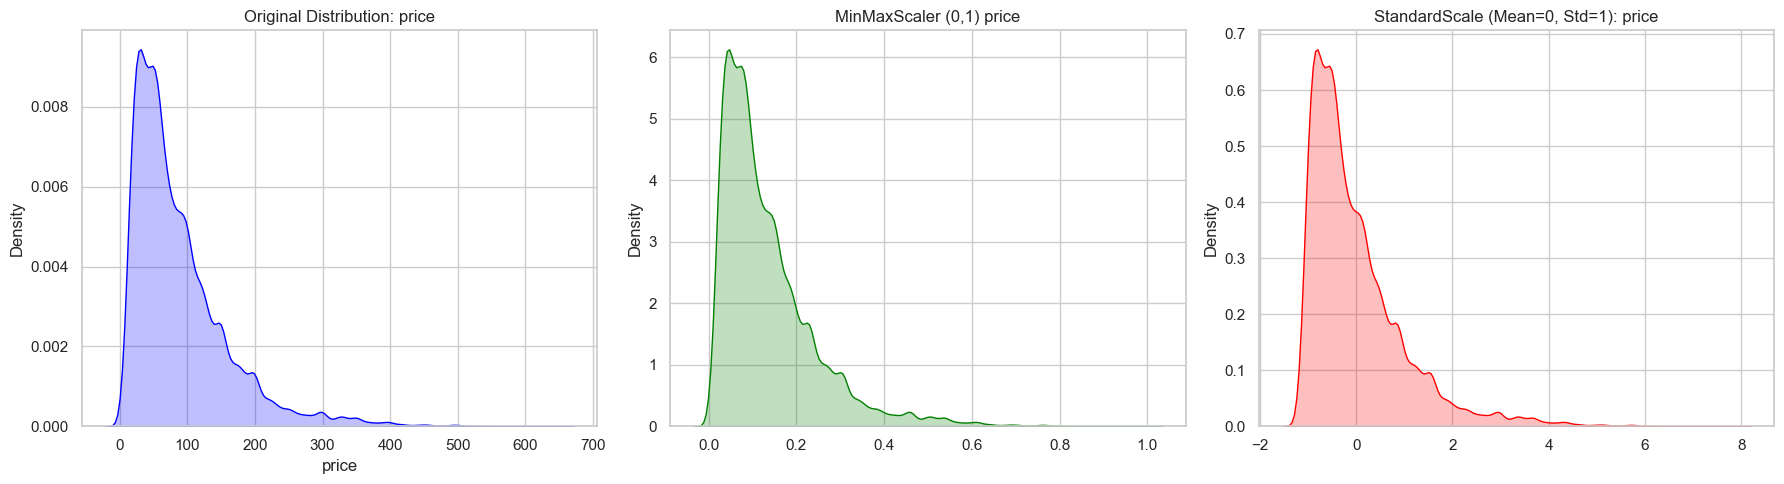

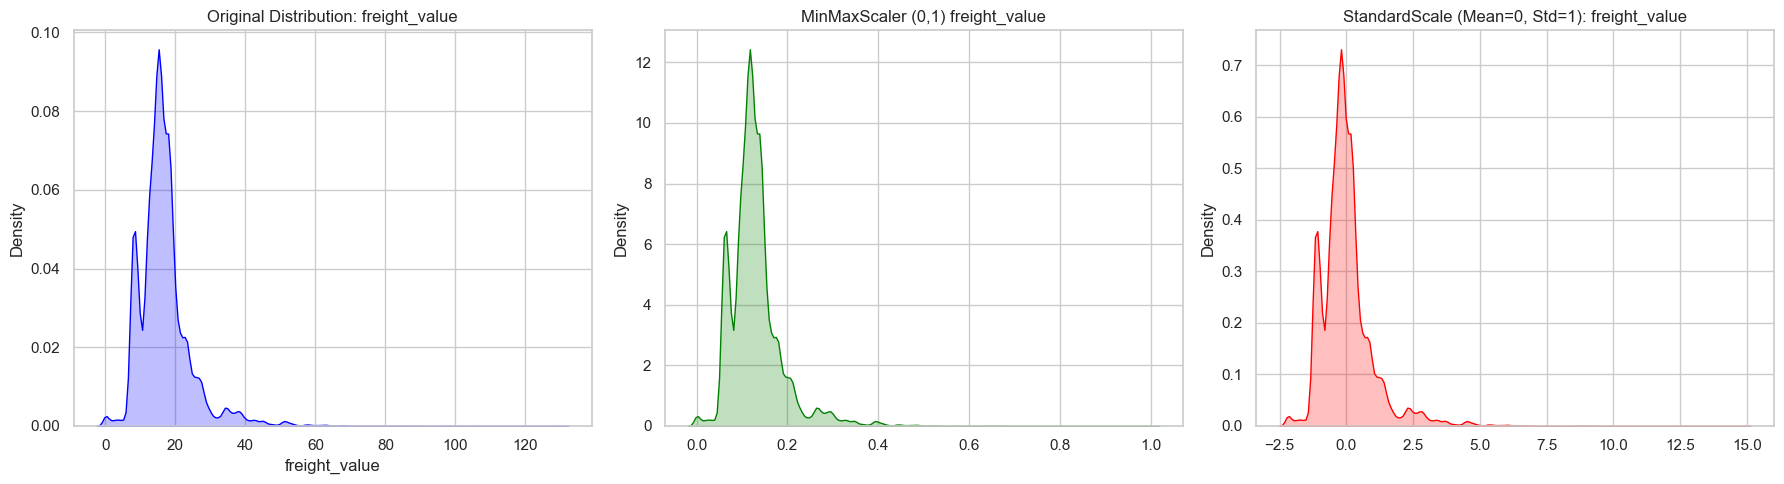

In [43]:
# Trực quan hóa kết quả mô tả lý do chọn Standardization 
cols_to_plot = ['price', 'freight_value']

# display(df_final.columns)
min_max_scaler = MinMaxScaler()
std_scaler = StandardScaler()

for col in cols_to_plot:
    data_original = df_final[[col]].copy() # hai dấu ngoặc vuông vì cta cần làm việc với sckitlearn -> trả về mảng 2 chiều
    data_minmax = min_max_scaler.fit_transform(data_original)
    data_std = std_scaler.fit_transform(data_original)

    fig, axes = plt.subplots(1,3, figsize=(18,5))
    sns.kdeplot(data_original[col], ax=axes[0], color='blue', fill=True)
    axes[0].set_title(f"Original Distribution: {col}")

    sns.kdeplot(data_minmax[:,0], ax=axes[1], color='green', fill=True)
    axes[1].set_title(f"MinMaxScaler (0,1) {col}")

    sns.kdeplot(data_std[:,0], ax=axes[2], color='red', fill=True)
    axes[2].set_title(f"StandardScale (Mean=0, Std=1): {col}")

    plt.tight_layout()
    plt.show()



### **d. Xử lý duplicate**

In [34]:
df_final =handle_duplicates(df_final)

--- XỬ LÝ TRÙNG LẶP HOÀN TẤT ---
- Số lượng dòng trùng lặp đã xóa: 10,219
- Kích thước dữ liệu sau khi xóa: (99970, 21)
------------------------------
